In [1]:
import pandas as pd
import glob

# Specify the file paths (adjust this if files are in different locations)
file_paths = ["ob_report_2025.csv", "ob_report_2024.csv", "ob_report_2023.csv"]  

# Read and concatenate all CSV files
df_list = [pd.read_csv(file) for file in file_paths]
combined_df = pd.concat(df_list, ignore_index=True)

# Save the combined data to a new CSV file
combined_df.to_csv("combined_file.csv", index=False)

print("CSV files combined successfully into 'combined_file.csv'")

CSV files combined successfully into 'combined_file.csv'


In [ ]:
print(combined_df)
#[2418 rows x 10 columns]

       _id                                   Institution Name  \
0        1                       True Davidson Acres - 4th Fl   
1        2    Kipling Acres - 2 South Elm & 2 North Highfield   
2        3  St.Clair O'Connor Community Nursing Home - 3rd Fl   
3        4                        The Millwood - 3rd & 4th Fl   
4        5                          Kennedy Lodge - Ground Fl   
...    ...                                                ...   
2413  1062    Isabel and Arthur Meighen Manor - Lawrence Unit   
2414  1063  North York General Hospital - Branson Site - 4...   
2415  1064  Sunnybrook Health Sciences Centre - Sunnybrook...   
2416  1065  Sunnybrook Health Sciences Centre - Sunnybrook...   
2417  1066  Villa Colombo Homes For The Aged - 5 Fusco Sou...   

        Institution Address       Outbreak Setting Type of Outbreak  \
0              200 Dawes Rd                   LTCH      Respiratory   
1          2223 Kipling Ave                   LTCH          Enteric   
2     

In [4]:
df = pd.DataFrame(data=combined_df)
df

,_id,Institution Name,Institution Address,Outbreak Setting,Type of Outbreak,Causative Agent-1,Causative Agent-2,Date Outbreak Began,Date Declared Over,Active
0,1,True Davidson Acres - 4th Fl,200 Dawes Rd,LTCH,Respiratory,Pending,NaN,2025-03-04,NaN,Y
1,2,Kipling Acres - 2 South Elm & 2 North Highfield,2223 Kipling Ave,LTCH,Enteric,Pending,NaN,2025-03-04,NaN,Y
2,3,St.Clair O'Connor Community Nursing Home - 3rd Fl,2701 St.Clair Ave E,LTCH,Respiratory,Coronavirus*,NaN,2025-03-04,NaN,Y
3,4,The Millwood - 3rd & 4th Fl,921 Millwood Rd,Retirement Home,Respiratory,Pending,NaN,2025-03-04,NaN,Y
4,5,Kennedy Lodge - Ground Fl,1400 Kennedy Rd,LTCH,Respiratory,Influenza A (H1N1),NaN,2025-03-03,NaN,Y
...,...,...,...,...,...,...,...,...,...,...
2413,1062,Isabel and Arthur Meighen Manor - Lawrence Unit,155 Millwood Rd,LTCH,Respiratory,COVID-19,NaN,2023-01-01,2023-02-21,N
2414,1063,North York General Hospital - Branson Site - 4...,555 Finch Avenue West,Hospital-Chronic Care,Respiratory,COVID-19,NaN,2023-01-01,2023-01-14,N
2415,1064,Sunnybrook Health Sciences Centre - Sunnybrook...,2075 Bayview Ave,LTCH,Respiratory,COVID-19,NaN,2023-01-01,2023-01-18,N
2416,1065,Sunnybrook Health Sciences Centre - Sunnybrook...,2075 Bayview Ave,LTCH,Respiratory,COVID-19,NaN,2023-01-01,2023-01-16,N


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "combined_file.csv"  # Change to your file name
df = pd.read_csv(file_path)

# Convert date columns to datetime
df['Date Outbreak Began'] = pd.to_datetime(df['Date Outbreak Began'])
df['Date Declared Over'] = pd.to_datetime(df['Date Declared Over'])

# Create 'Year-Month' column for trend analysis
df['Year-Month'] = df['Date Outbreak Began'].dt.to_period('M')
df['Year-Month']



0       2025-03
1       2025-03
2       2025-03
3       2025-03
4       2025-03
         ...   
2413    2023-01
2414    2023-01
2415    2023-01
2416    2023-01
2417    2023-01
Name: Year-Month, Length: 2418, dtype: period[M]

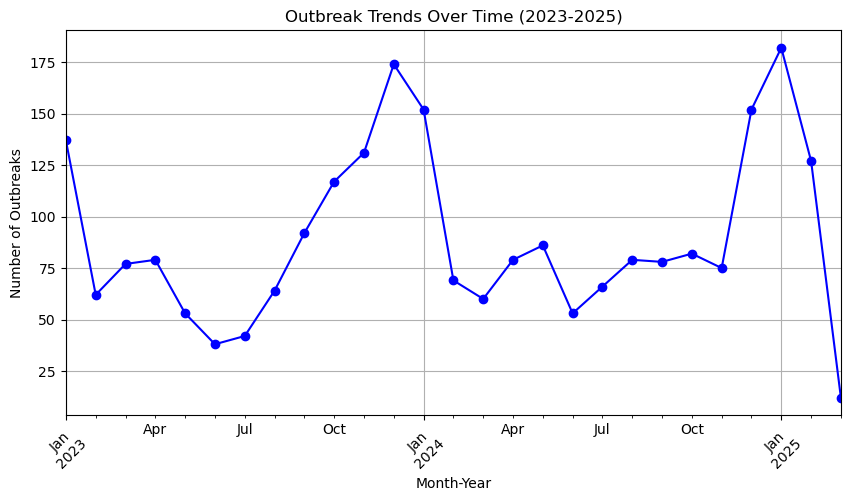

In [8]:
# ---- 1. Outbreak Trends Over Time ----
plt.figure(figsize=(10, 5))
outbreak_trend = df.groupby('Year-Month').size()
outbreak_trend.plot(kind='line', marker='o', color='b')
plt.title('Outbreak Trends Over Time (2023-2025)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Outbreaks')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14212\3561813067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_agents.index, y=top_agents.values, palette='viridis')


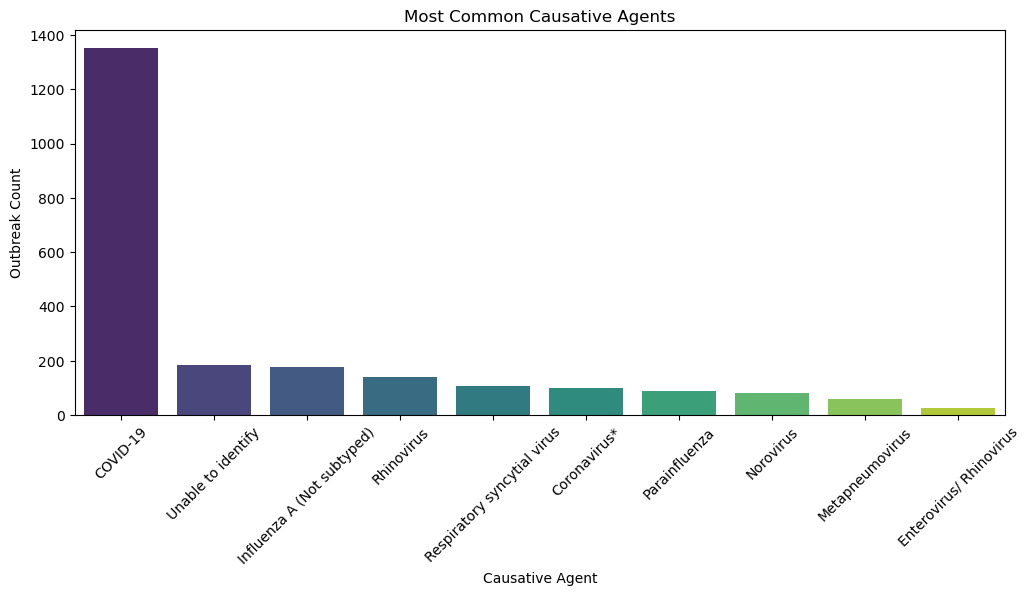

In [9]:
# ---- 2. Common Causative Agents ----
plt.figure(figsize=(12, 5))
top_agents = df['Causative Agent-1'].value_counts().head(10)  # Top 10 agents
sns.barplot(x=top_agents.index, y=top_agents.values, palette='viridis')
plt.title('Most Common Causative Agents')
plt.xlabel('Causative Agent')
plt.ylabel('Outbreak Count')
plt.xticks(rotation=45)
plt.show()



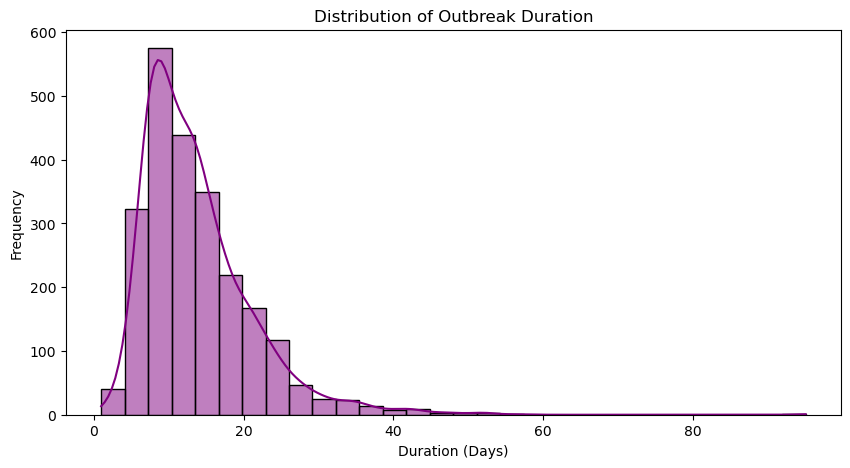

In [10]:
# ---- 3. Outbreak Duration Analysis ----
# Calculate duration in days
df['Outbreak Duration'] = (df['Date Declared Over'] - df['Date Outbreak Began']).dt.days

# Histogram of outbreak duration
plt.figure(figsize=(10, 5))
sns.histplot(df['Outbreak Duration'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of Outbreak Duration')
plt.xlabel('Duration (Days)')
plt.ylabel('Frequency')
plt.show()

